---
title: "Лабораторна робота 5. Метод опорних векторів (SVM). Методи оцінки якості моделі"
description:
  __Розпізнавання образів та комп'ютерний зір__
author: Denys Harahulia
date: "04.07.2026"
lang: ukr
format:
  html:
    code-fold: true
    toc: true # меню
    toc_float: # спливаюче меню  
      collapsed: true # авто
      number_sections: true
jupyter: python3
---

**Мета**: закріпити на практиці концепцію SVM-моделі засобами мови Python

## Завдання для самостійної роботи 

1. Реалізувати SVM-класифікатор з лінійним і різними нелінійним ядрами згідно з варіантом.
1. Проаналізувати іпорівняти результати класифікації, обчисливши відповідні метрики.
1. Вибрати найкращу модель. Результат обґрунтувати.
1. Дати відповіді на контрольні запитання.
1. Відправити результати роботи у файлі lab_5_StudentLastName.ipynb до віддаленого репозиторію на GіtHub

[ 0.05936941 -0.13338318 -0.00676801]
[[18. 17.  1.]
 [30. 36.  1.]
 [38.  6.  1.]]


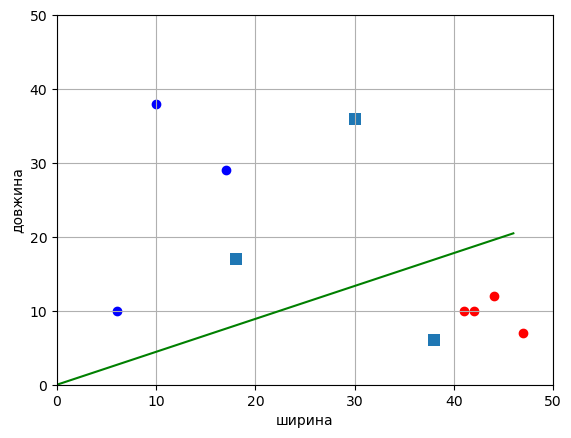

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

# Навчальний набір даних з трьома ознаками (третя - постійна +1)
x_train = [[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]]
x_train = [x + [1] for x in x_train]
y_train = [-1, 1, 1, -1, -1, -1, 1, -1, 1, 1]

clf = svm.SVC(kernel='linear')      # Метод опорних векторів з лінійним ядром
clf.fit(x_train, y_train)           # Знаходження вектора w за навчальним набором даних

lin_clf = svm.LinearSVC()           # Метод опорних векторів для лінійно роздільного набору даних (використовується для отримання вектора w)
lin_clf.fit(x_train, y_train)       # Знаходження вектора w за навчальним набором даних

v = clf.support_vectors_            # Виділення опорних векторів
w = lin_clf.coef_[0]                # Коефіцієнти лінійної моделі
print(w, v, sep='\n')

# Формування графіків для візуалізації отриманих результатів
x_train = np.array(x_train)
y_train = np.array(y_train)
line_x = list(range(max(x_train[:, 0])))    # Формування графіка роздільної лінії
line_y = [-x*w[0]/w[1] - w[2] for x in line_x]

x_0 = x_train[y_train == 1]                 # Формування точок для першого
x_1 = x_train[y_train == -1]                # та другого класів

plt.scatter(x_0[:, 0], x_0[:, 1], color='red')
plt.scatter(x_1[:, 0], x_1[:, 1], color='blue')
plt.scatter(v[:, 0], v[:, 1], s=70, edgecolor=None, linewidths=0, marker='s')
plt.plot(line_x, line_y, color='green')

plt.xlim([0, 50])
plt.ylim([0, 50])
plt.ylabel("довжина")
plt.xlabel("ширина")
plt.grid(True)
plt.show()


Support vectors:
 [[18. 17.  1.]
 [30. 36.  1.]
 [ 6. 10.  1.]
 [44. 12.  1.]
 [38.  6.  1.]
 [41. 10.  1.]]


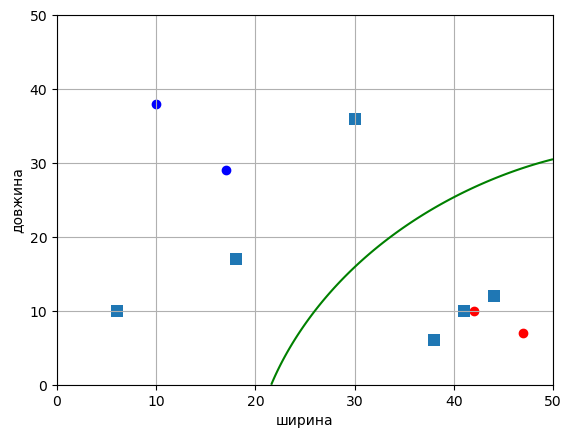

In [2]:
# Навчальний набір даних
x_train = [[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]]
x_train = [x + [1] for x in x_train]
y_train = [-1, 1, 1, -1, -1, -1, 1, -1, 1, 1]

# SVM з нелінійним ядром (RBF)
clf = svm.SVC(kernel='rbf', gamma='scale', C=1.0)
clf.fit(x_train, y_train)

v = clf.support_vectors_   # Опорні вектори
print("Support vectors:\n", v)

# Візуалізація
x_train = np.array(x_train)
y_train = np.array(y_train)

x_0 = x_train[y_train == 1]
x_1 = x_train[y_train == -1]

plt.scatter(x_0[:, 0], x_0[:, 1], color='red')
plt.scatter(x_1[:, 0], x_1[:, 1], color='blue')
plt.scatter(v[:, 0], v[:, 1], s=70, edgecolor=None, linewidths=0, marker='s')

# Побудова нелінійної роздільної межі
xx, yy = np.meshgrid(np.linspace(0, 50, 200),
                     np.linspace(0, 50, 200))

grid = np.c_[xx.ravel(), yy.ravel(), np.ones(xx.ravel().shape)]
Z = clf.decision_function(grid)
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0], colors='green')

plt.xlim([0, 50])
plt.ylim([0, 50])
plt.ylabel("довжина")
plt.xlabel("ширина")
plt.grid(True)
plt.show()

Support vectors:
 [[18. 17.  1.]
 [30. 36.  1.]
 [38.  6.  1.]]


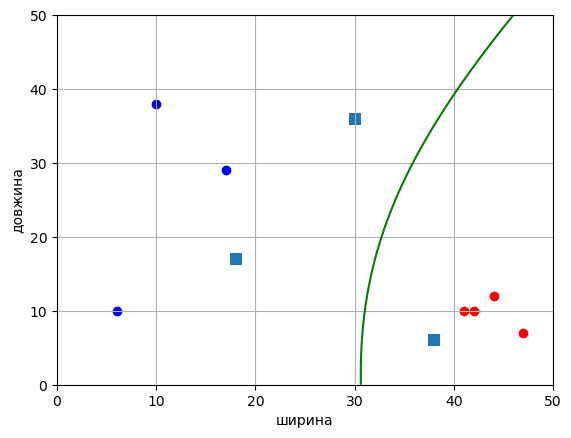

In [3]:
# Навчальний набір даних
x_train = [[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]]
x_train = [x + [1] for x in x_train]
y_train = [-1, 1, 1, -1, -1, -1, 1, -1, 1, 1]

# SVM з нелінійним ядром (RBF)
clf = svm.SVC(kernel='poly', degree=3)
clf.fit(x_train, y_train)

v = clf.support_vectors_   # Опорні вектори
print("Support vectors:\n", v)

# Візуалізація
x_train = np.array(x_train)
y_train = np.array(y_train)

x_0 = x_train[y_train == 1]
x_1 = x_train[y_train == -1]

plt.scatter(x_0[:, 0], x_0[:, 1], color='red')
plt.scatter(x_1[:, 0], x_1[:, 1], color='blue')
plt.scatter(v[:, 0], v[:, 1], s=70, edgecolor=None, linewidths=0, marker='s')

# Побудова нелінійної роздільної межі
xx, yy = np.meshgrid(np.linspace(0, 50, 200),
                     np.linspace(0, 50, 200))

grid = np.c_[xx.ravel(), yy.ravel(), np.ones(xx.ravel().shape)]
Z = clf.decision_function(grid)
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0], colors='green')

plt.xlim([0, 50])
plt.ylim([0, 50])
plt.ylabel("довжина")
plt.xlabel("ширина")
plt.grid(True)
plt.show()

Support vectors:
 [[17. 29.  1.]
 [18. 17.  1.]
 [30. 36.  1.]
 [ 6. 10.  1.]
 [10. 38.  1.]
 [44. 12.  1.]
 [47.  7.  1.]
 [38.  6.  1.]
 [41. 10.  1.]
 [42. 10.  1.]]


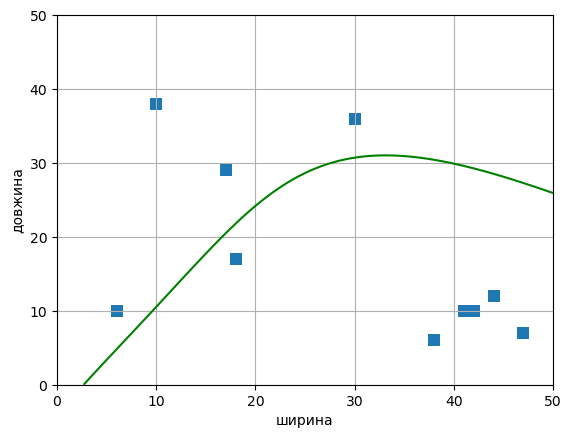

In [4]:
# Навчальний набір даних
x_train = [[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10], [38, 6], [10, 38], [41, 10], [42, 10]]
x_train = [x + [1] for x in x_train]
y_train = [-1, 1, 1, -1, -1, -1, 1, -1, 1, 1]

# SVM з нелінійним ядром (RBF)
clf = svm.SVC(kernel='sigmoid')
clf.fit(x_train, y_train)

v = clf.support_vectors_   # Опорні вектори
print("Support vectors:\n", v)

# Візуалізація
x_train = np.array(x_train)
y_train = np.array(y_train)

x_0 = x_train[y_train == 1]
x_1 = x_train[y_train == -1]

plt.scatter(x_0[:, 0], x_0[:, 1], color='red')
plt.scatter(x_1[:, 0], x_1[:, 1], color='blue')
plt.scatter(v[:, 0], v[:, 1], s=70, edgecolor=None, linewidths=0, marker='s')

# Побудова нелінійної роздільної межі
xx, yy = np.meshgrid(np.linspace(0, 50, 200),
                     np.linspace(0, 50, 200))

grid = np.c_[xx.ravel(), yy.ravel(), np.ones(xx.ravel().shape)]
Z = clf.decision_function(grid)
Z = Z.reshape(xx.shape)

plt.contour(xx, yy, Z, levels=[0], colors='green')

plt.xlim([0, 50])
plt.ylim([0, 50])
plt.ylabel("довжина")
plt.xlabel("ширина")
plt.grid(True)
plt.show()

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Дані
x_train = [[17, 29], [44, 12], [47, 7], [18, 17], [30, 36], [6, 10],
           [38, 6], [10, 38], [41, 10], [42, 10]]
x_train = [x + [1] for x in x_train]
y_train = [-1, 1, 1, -1, -1, -1, 1, -1, 1, 1]

x_train = np.array(x_train)
y_train = np.array(y_train)

# Моделі
models = {
    "Linear": svm.SVC(kernel='linear'),
    "RBF": svm.SVC(kernel='rbf', gamma='scale'),
    "Polynomial": svm.SVC(kernel='poly', degree=3),
    "Sigmoid": svm.SVC(kernel='sigmoid')
}

results = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_train)

    results[name] = {
        "accuracy": accuracy_score(y_train, y_pred),
        "precision": precision_score(y_train, y_pred),
        "recall": recall_score(y_train, y_pred),
        "f1": f1_score(y_train, y_pred)
    }

# Вивід результатів
for name, metrics in results.items():
    print(f"\n{name}")
    for m, value in metrics.items():
        print(f"{m}: {value:.3f}")

# Вибір найкращої моделі
best_model = max(results, key=lambda x: results[x]["f1"])
print("\nНайкраща модель:", best_model)


Linear
accuracy: 1.000
precision: 1.000
recall: 1.000
f1: 1.000

RBF
accuracy: 1.000
precision: 1.000
recall: 1.000
f1: 1.000

Polynomial
accuracy: 1.000
precision: 1.000
recall: 1.000
f1: 1.000

Sigmoid
accuracy: 0.900
precision: 0.833
recall: 1.000
f1: 0.909

Найкраща модель: Linear
